In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from matplotlib.animation import FuncAnimation
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import hdbscan
import math
import os

In [10]:
def safe_zscore(x):
    std = x.std()
    if std == 0 or pd.isna(std):
        return 0
    return (x - x.mean()) / std

def merge_ranks(df):
    temp_df = df[(df['rank'] != 'potential-smurfs-enaka01dhi') & (df['rank'] != '.ipynb_checkpoints')].copy()
    for i in temp_df.index:
        temp_rank = temp_df.loc[i, 'rank']
        if temp_rank != 'supersonic-legend':
            temp_rank = temp_rank[:-2]
            temp_df.loc[i, 'rank'] = temp_rank
    return temp_df

In [14]:
master_df = pd.read_csv('replay_csvs/master_replays.csv')
master_df = master_df.drop(columns=['team name'])
features = master_df.select_dtypes(include=['number']).columns.drop('smurf')

#master_df[features] = master_df.groupby('rank')[features].transform(safe_zscore)
master_df = merge_ranks(master_df)

numeric_df = master_df.select_dtypes(include=['number'])
meta_df = master_df.select_dtypes(exclude=['number'])

In [15]:
for i in master_df.columns:
    print(i)

replay_id
playlist
rank
color
player name
platform
player id
car id
car name
game duration
score
goals
assists
saves
shots
shots conceded
goals conceded
goals conceded while last defender
shooting percentage
bpm
avg boost amount
amount collected
amount collected big pads
amount collected small pads
count collected big pads
count collected small pads
amount stolen
amount stolen big pads
amount stolen small pads
count stolen big pads
count stolen small pads
0 boost time
100 boost time
amount used while supersonic
amount overfill total
amount overfill stolen
avg speed
total distance
time slow speed
percentage slow speed
time boost speed
percentage boost speed
time supersonic speed
percentage supersonic speed
time on ground
percentage on ground
time low in air
percentage low in air
time high in air
percentage high in air
time powerslide
avg powerslide time
count powerslide
time most back
time most forward
avg distance to ball
avg distance to ball has possession
avg distance to ball no poss

In [16]:
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)

numeric_coords = TSNE(n_components=2,perplexity=20,random_state=42).fit_transform(numeric_scaled)
tsne_df = pd.DataFrame(numeric_coords, columns=['tsne_1', 'tsne_2'], index=numeric_df.index)
master_tsne = pd.concat([meta_df, numeric_df, tsne_df],axis=1)

In [17]:
lof = LocalOutlierFactor(n_neighbors=20)
scores = -lof.fit_predict(numeric_scaled)

master_tsne['lof_score'] = lof.negative_outlier_factor_

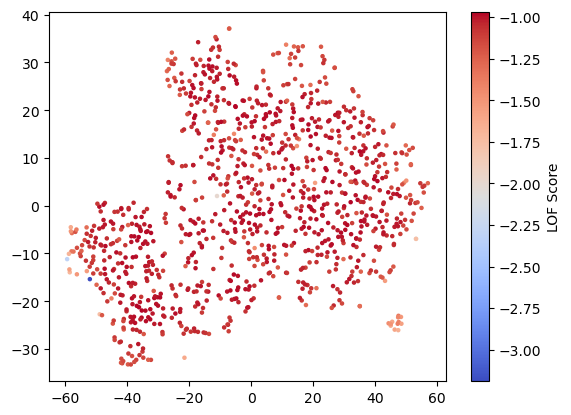

In [18]:
plt.scatter(tsne_df['tsne_1'], tsne_df['tsne_2'], 
            c=master_tsne['lof_score'], cmap='coolwarm', s=5)
plt.colorbar(label='LOF Score')
plt.show()

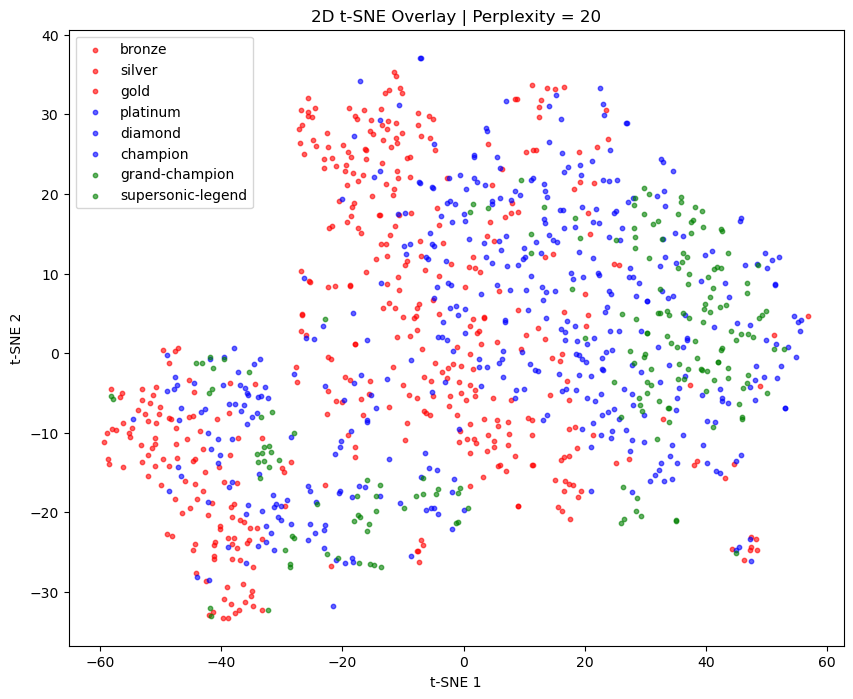

In [19]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

colors = {'bronze': 'red','silver': 'red','gold': 'red','platinum': 'blue',
        'diamond': 'blue', 'champion': 'blue','grand-champion': 'green', 'supersonic-legend': 'green'}

point_colors = master_tsne['rank'].map(colors).fillna('black')

for rank, color in colors.items():
    mask = master_tsne['rank'] == rank
    ax.scatter(
        numeric_coords[mask, 0],
        numeric_coords[mask, 1],
        c=color,
        label=rank,
        s=10,
        alpha=0.6
    )

ax.set_title(f"2D t-SNE Overlay | Perplexity = 20")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()
plt.show()

C:\Users\rcand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\rcand\AppData\Local\Temp\ipykernel_5252\1330724046.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


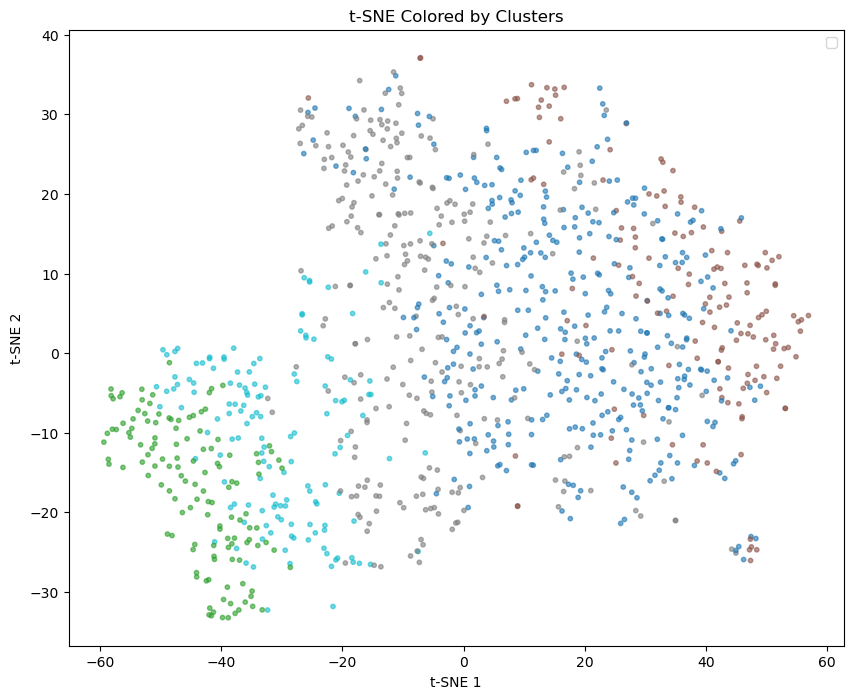

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)
master_tsne['cluster'] = kmeans.fit_predict(numeric_df.values)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

scatter = ax.scatter(
    master_tsne['tsne_1'],
    master_tsne['tsne_2'],
    c=master_tsne['cluster'],
    cmap='tab10',
    s=10,
    alpha=0.6
)

ax.set_title("t-SNE Colored by Clusters")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend()

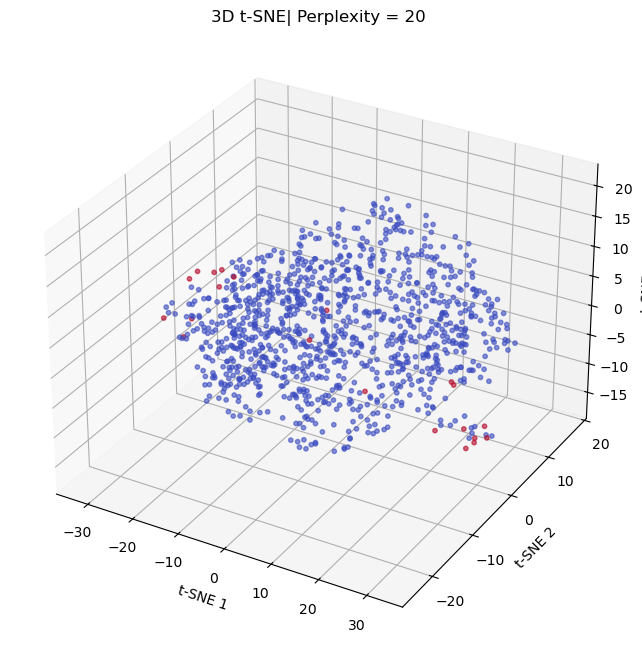

In [29]:
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(numeric_df)

coords_3d = TSNE(n_components=3, perplexity=20, random_state=42).fit_transform(numeric_scaled)

lof_3d = LocalOutlierFactor(n_neighbors=20)
scores_3d = -lof.fit_predict(numeric_scaled)
outlier_score_3d = -lof.negative_outlier_factor_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    coords_3d[:, 0],
    coords_3d[:, 1],
    coords_3d[:, 2],
    c=scores_3d,
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

ax.set_title(f"3D t-SNE| Perplexity = 20")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.show()

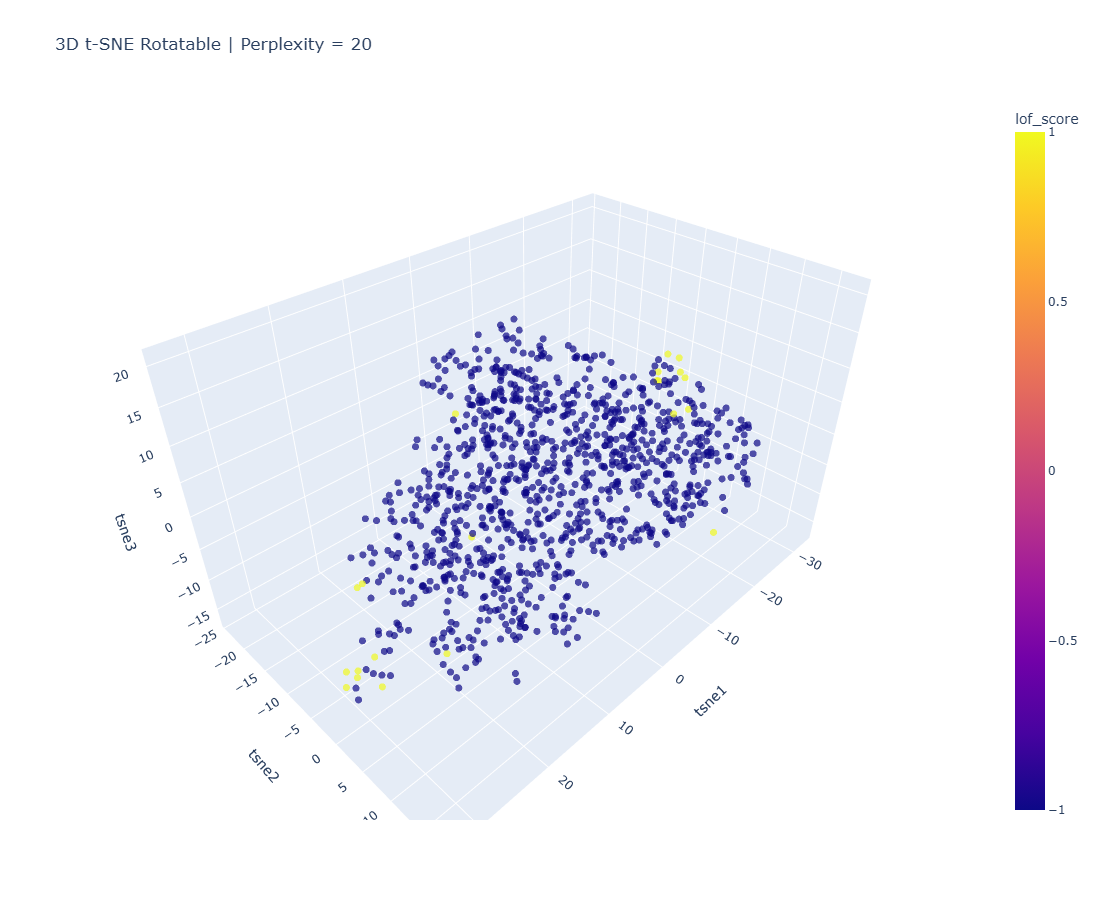

In [37]:
plot_df = pd.DataFrame(coords_3d, columns=["tsne1", "tsne2", "tsne3"])
plot_df["lof_score"] = scores_3d

fig = px.scatter_3d(
    plot_df,
    x="tsne1",
    y="tsne2",
    z="tsne3",
    color="lof_score",
    color_continuous_scale="Plasma",
    opacity=0.7,
    hover_data=["lof_score"],
    title=f"3D t-SNE Rotatable | Perplexity = 20",
    width=1200,
    height=900
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [22]:
suspects = master_tsne.nsmallest(50, 'lof_score')
suspects

,replay_id,playlist,rank,color,player name,platform,player id,car name,demos taken,car id,...,time neutral third,percentage neutral third,time offensive third,percentage offensive third,demos inflicted,smurf,tsne_1,tsne_2,lof_score,cluster
547,77fb842b-faa2-4efb-bbd0-e0edbd6e3b99,Ranked Doubles,bronze,orange,Orangesig32,Epic,1e9b7c9e60e6404786a7ba56d9bbad52,Fennec,0,4284,...,0.00,0.00,0.00,0.00,0,0,-52.062176,-15.374219,-3.189780,1
519,72c0aabc-d482-40d0-8e4a-0d7aa491e700,Ranked Doubles,gold,orange,DR.J,Psynet,24dc0f85ad08b1bb,Dominus,0,403,...,0.00,0.00,0.00,0.00,0,0,-59.387321,-11.182762,-2.306849,1
496,6b7ac4b2-5ee6-42a2-9682-d99572d8d489,Ranked Doubles,platinum,blue,rage10b,Steam,76561198841096308,Octane,0,23,...,102.91,26.81,144.11,37.54,10,0,53.138691,-6.937934,-2.023542,2
295,3a371ff8-84c4-46aa-86d3-7f750e1ae64b,Ranked Doubles,bronze,orange,SimilarPerch5471,PS4,SimilarPerch5471,Dominus,1,403,...,100.80,26.18,61.05,15.85,1,0,-11.043473,2.032104,-1.997088,3
93,0ed54d94-599d-48e7-8915-33f0fd5d4452,Ranked Doubles,bronze,blue,lxstomania,Epic,83946706c682428c9a1633419ba94952,Fennec,0,4284,...,2.41,14.80,6.08,37.35,0,0,-48.888618,-22.730206,-1.761263,1
1099,fe77ce49-2f20-463f-bf3e-b083b52e8a07,Ranked Doubles,platinum,orange,rage10b,Steam,76561198841096308,Octane,0,23,...,116.64,27.07,126.07,29.26,7,0,53.138966,-6.942374,-1.755763,2
723,a1ffb819-0be3-4a83-9b80-f535b8961179,Ranked Doubles,silver,orange,C.Reach_Around,Epic,12d18acb686a402caec3a5a1cc0aee22,Fennec,0,4284,...,26.01,24.84,47.33,45.20,0,0,-58.544228,-13.943691,-1.700569,1
965,da71254f-8dd7-49de-902e-0a4c179d8dcf,Ranked Doubles,gold,blue,RL DADLESS,Epic,1fe7e6dce31b45e984f89663f6bba597,Octane,0,23,...,4.72,4.76,5.90,5.96,0,0,-58.816025,-10.079020,-1.681519,1
158,1c60c16e-dfa1-43c5-8e16-e16f40b67cc2,Ranked Doubles,platinum,orange,R3d-B3ar,Epic,dd2534e4a26b4423908dbda2e780e8dc,Dominus,1,403,...,149.12,34.89,106.99,25.03,0,1,47.397675,-26.054287,-1.657696,2
388,4cd59261-e94a-4cf9-8dfb-39969afaec1d,Ranked Doubles,grand-champion,blue,Timee93,PS4,Timee93,Octane,0,23,...,99.01,32.81,75.07,24.88,0,1,44.980320,-25.116085,-1.631469,3


In [23]:
suspects['rank'].value_counts()

rank
bronze               15
gold                  9
platinum              8
silver                8
supersonic-legend     4
champion              3
grand-champion        2
diamond               1
Name: count, dtype: int64

In [24]:
X = master_tsne.select_dtypes(include=['number']).drop(columns=['smurf', 'car id', 'tsne_1', 'tsne_2'],errors='ignore')
y = master_tsne['smurf']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [25]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, scale_pos_weight=scale_pos_weight)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       211
           1       1.00      0.67      0.80         3

    accuracy                           1.00       214
   macro avg       1.00      0.83      0.90       214
weighted avg       1.00      1.00      0.99       214



In [26]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred))
pd.DataFrame({
    'true': y_test,
    'prob': y_prob
}).sort_values('prob', ascending=False)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       211
           1       1.00      0.67      0.80         3

    accuracy                           1.00       214
   macro avg       1.00      0.83      0.90       214
weighted avg       1.00      1.00      0.99       214



,true,prob
628,1,0.999227
502,1,0.999140
264,1,0.073022
886,0,0.028061
734,0,0.020648
...,...,...
848,0,0.000254
485,0,0.000254
479,0,0.000254
987,0,0.000254


In [27]:
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

lof_score                      0.847009
goals                          0.081189
percentage behind ball         0.031427
percentage boost speed         0.007746
percentage slow speed          0.005444
percentage high in air         0.003733
percentage supersonic speed    0.003494
time in front of ball          0.003367
avg speed                      0.002839
score                          0.002551
dtype: float32


In [28]:
X_no_lof = X.drop(columns=['lof_score'], errors='ignore')

model_no_lof = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model_no_lof.fit(X_train[X_no_lof.columns], y_train)
y_pred_no_lof = model_no_lof.predict(X_test[X_no_lof.columns])
y_prob_no_lof = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_no_lof))

pd.DataFrame({
    'true': y_test,
    'prob': y_prob_no_lof
}).sort_values('prob', ascending=False)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       211
           1       0.67      0.67      0.67         3

    accuracy                           0.99       214
   macro avg       0.83      0.83      0.83       214
weighted avg       0.99      0.99      0.99       214



,true,prob
628,1,0.999227
502,1,0.999140
264,1,0.073022
886,0,0.028061
734,0,0.020648
...,...,...
848,0,0.000254
485,0,0.000254
479,0,0.000254
987,0,0.000254
